# Insurance Pricing Model: Modeling

There are many more steps that could be done before jumping directly into modeling, but for the sake of brevity, we'll jump right in to building models.

I'm going to very briefly train 3 different kinds of models on this data and compare their out-of-sample performance.

1. **Ordinary Least Squares Regression** (OLS): This is not an inherently bad modeling technique in every case, but it is a bad choice for our data. We'll go over why, but I want to use it as a baseline to start our work from.
2. **Generalized Linear Model** (GLM): This is a traditionally-accepted general practice model for actuaries modeling insurance losses. It is very good. It also has *some* limitations that I'll go over. I won't demonstrate, but I'll discuss some ways to improve upon a basic GLM.
3. **Gradient Boosting Machine** (GBM) implemented via XGBoost: This is the "cutting edge" modeling technique for modeling insurance losses in the United States as of today. I'm currently training models with this methodology and often run into issues with regulatory reviewers because of how uncommon (and some would argue unproven) it is.

# Packages and Settings

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import xgboost as xgb
from xgboost import XGBRegressor
from utils import *

# Import Data

In [2]:
df = pd.read_parquet("data/df_train.parquet")

# Train Ordinary Least Squares Regression

Recall that for OLS, we are estimating the coefficients in a formula like this:

$$
\begin{aligned}
\mathbb{E}[\text{ClaimAmount\_capped\_1MIL}]
&= \beta_0
+ \beta_1 \,\text{VehPower}
+ \beta_2 \,\text{VehAge}
+ \beta_3 \,\text{DrivAge} \\
&\quad
+ \beta_4 \,\text{BonusMalus}
+ \beta_5 \,\text{Density}
+ \sum_j \gamma_j \,\mathbb{1}(\text{Area}=j)
+ \sum_k \delta_k \,\mathbb{1}(\text{VehBrand}=k) \\
&\quad
+ \sum_m \eta_m \,\mathbb{1}(\text{VehGas}=m)
+ \sum_r \theta_r \,\mathbb{1}(\text{Region}=r)
\end{aligned}
$$

A couple of notes about the below model parameterization:

1. I used ClaimAmount_capped_1MIL. Not uncapped and not one of the other capping scenarios. Outside the scope of this project, I did some analysis that suggests this is the "best" target. It removes some astoundingly large individual claims that impact the model's ability to generalize.
2. Note I'm only fitting a "straight-line" to the numeric columns. We noted during EDA that these are not necessarily straight-line relationships. Handling this is outside our scope today.
3. Note the categorical variables are using potentially very small and potentially uncredible categories. Again, this was noted during EDA and outside our scope today.
4. We are not including any interaction terms. Again, outside the scope today.

Overall, I would not expect OLS or GLM under this simpler model form to perform to the best of their ability.

In [ ]:
y_col = "ClaimAmount_capped_1MIL"

cat_cols = ["Area", "VehBrand", "VehGas", "Region"]
num_cols = ["VehPower", "VehAge", "DrivAge", "BonusMalus", "Density"]

rhs = " + ".join(
    [f"C({c})" for c in cat_cols] + num_cols
)

formula = f"{y_col} ~ {rhs}"

ols = smf.ols(
    formula=formula,
    data=df
).fit() 

print(ols.summary())

                               OLS Regression Results                              
Dep. Variable:     ClaimAmount_capped_1MIL   R-squared:                       0.000
Model:                                 OLS   Adj. R-squared:                  0.000
Method:                      Least Squares   F-statistic:                     4.760
Date:                     Tue, 20 Jan 2026   Prob (F-statistic):           2.00e-22
Time:                             23:18:45   Log-Likelihood:            -5.1250e+06
No. Observations:                   542410   AIC:                         1.025e+07
Df Residuals:                       542367   BIC:                         1.025e+07
Df Model:                               42                                         
Covariance Type:                 nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

The coefficient estimates are in the "coef" column. The P>|t| column gives you the p-value for a hypothesis test of whether or not the coefficient is significantly different from 0...as long as the model is valid, this is useful output.

The model fit. I must be done...right?

Why is this not a good idea? Does anyone know?

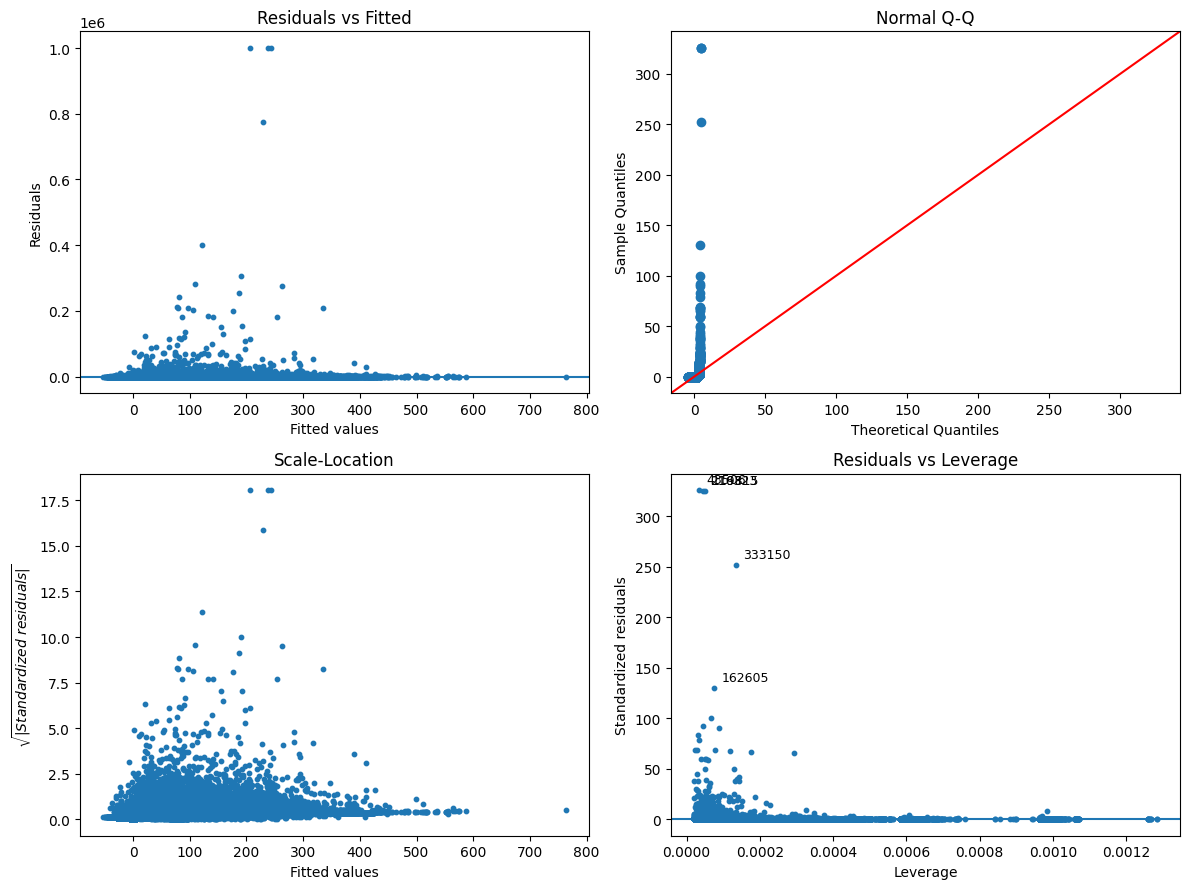

In [4]:
fitted = ols.fittedvalues
resid = ols.resid

infl = ols.get_influence()
std_resid = infl.resid_studentized_internal
leverage = infl.hat_matrix_diag
cooks = infl.cooks_distance[0]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
ax1, ax2, ax3, ax4 = axes.ravel()

# 1) Residuals vs Fitted
ax1.scatter(fitted, resid, s=10)
ax1.axhline(0)
ax1.set_title("Residuals vs Fitted")
ax1.set_xlabel("Fitted values")
ax1.set_ylabel("Residuals")

# 2) Normal Q-Q
sm.qqplot(std_resid, line="45", ax=ax2)
ax2.set_title("Normal Q-Q")

# 3) Scale-Location
ax3.scatter(fitted, np.sqrt(np.abs(std_resid)), s=10)
ax3.set_title("Scale-Location")
ax3.set_xlabel("Fitted values")
ax3.set_ylabel(r"$\sqrt{|Standardized\ residuals|}$")

# 4) Residuals vs Leverage (label a few high Cook's distance points)
ax4.scatter(leverage, std_resid, s=10)
ax4.axhline(0)
ax4.set_title("Residuals vs Leverage")
ax4.set_xlabel("Leverage")
ax4.set_ylabel("Standardized residuals")

# label top 5 Cook's distance points
top = np.argsort(cooks)[-5:]
for i in top:
    ax4.annotate(str(i), (leverage[i], std_resid[i]), xytext=(5, 5),
                 textcoords="offset points", fontsize=9)

plt.tight_layout()
plt.show()

Ordinary least squares regression has some assumptions behind it. If any of those assumptions are violated, the model is invalid.

Does anyone remember the assumptions?

(Don't scroll down yet)





















...

1. Linearity: The mean of Y is a linear function of the predictors.
2. Independence: Observations (errors) are independent of each other.
3. Constant variance (Homoskedasticity): The error variance is the same for all fitted values.
4. Normality of errors: The errors are approximately normally distributed. This is *technically* necessary for inference, but not strictly necessary for prediction.

In the above diagnostic plots, we see a clear violation of a couple of these assumptions:

1. Residuals vs Fitted and Scale-Location plots clearly show a violation of assumption #3: the variance is NOT constant and does not depend on the mean.
2. The QQ-plot clearly shows a violation of assumption #4: the residuals are not close to that straight line- they are NOT normal. They show signs of extreme skewness.

Some more bad things:

1. There are some high-leverage outlier observations driving the model fit (see Residuals vs Leverage plot)
2. See below- fitted values are nonsensical.

In [5]:
print(ols.fittedvalues.sort_values().head(10))
print(f"{((ols.fittedvalues < 0).sum() / len(ols.fittedvalues)).round(3) * 100}% of our training data has a negative prediction.")

61613    -53.158854
123903   -50.193726
238168   -50.036193
140925   -48.820823
135844   -46.086033
135843   -46.086033
248452   -45.928500
487793   -45.535926
324700   -45.334822
628630   -44.280129
dtype: float64
3.2% of our training data has a negative prediction.


The model fit negative values to some of our risks. If we used this model, we'd be GIVING money to our insureds for their business. INSANE!

It may seem CRAZY that someone would use this model to fit insurance losses, but I can assure you it HAPPENS. 

When I first became a modeler and took over an existing pricing model for my first project, THIS was the form of our production model used to price tens of millions of dollars of premium and yes- it predicted negative pure premium for some risks. I gained a lot of credibility as a modeler at my job by fixing this problem.

# Train Generalized Linear Model

While this trains (takes about 40 seconds)...

What makes a GLM different than OLS?

OLS assumes normal errors with constant variance and an identity link; a GLM lets you choose the error distribution and a link function so the model matches the data. The variance of is allowed to depend on the mean in a GLM instead of being constant. OLS is a special case of GLM, but GLM loosens the strict assumptions and lets you work with different data.

We discussed this earlier, but insurance losses have a point-mass at 0 and then some sort of skewed distribution for >0. The exact shape >0 could be a little bit different between datasets. There is a special distribution for this: Tweedie distribution. Just like you've already heard of normal distribution, binomial, Poisson, Gamma, etc. Tweedie is just another distribution. It's also called a Compound Poisson-Gamma Distribution.

$\operatorname{Var}(Y) = \sigma^2 \mu^{p}$

It has one parameter, *p*. Remember normal distribution has 2: ($\mu$, $\sigma$), binomial has 1: *p*, poisson has 1: $\lambda$

*p* for a Tweedie describes how skewed things are. Here are some examples of a simulated Tweedie distribution:

![Tweedie power demo](./img/tweedie_power_demo.png)

For our data, I performed some analysis outside of this project to estimate this parameter for our data. I pass this parameter to the GLM fit: 1.94.


We also use a log-link. This is common practice. We are fitting estimates to coefficients in this formula:

$$
\begin{aligned}
\log\!\big(\mathbb{E}[\text{ClaimAmount\_capped\_1MIL}]\big)
&= \beta_0
+ \beta_1 \,\text{VehPower}
+ \beta_2 \,\text{VehAge}
+ \beta_3 \,\text{DrivAge} \\
&\quad
+ \beta_4 \,\text{BonusMalus}
+ \beta_5 \,\text{Density}
+ \sum_j \gamma_j \,\mathbb{1}(\text{Area}=j)
+ \sum_k \delta_k \,\mathbb{1}(\text{VehBrand}=k) \\
&\quad
+ \sum_m \eta_m \,\mathbb{1}(\text{VehGas}=m)
+ \sum_r \theta_r \,\mathbb{1}(\text{Region}=r)
\end{aligned}
$$

In [6]:
glm = smf.glm(
    formula=formula,
    data=df,
    family=sm.families.Tweedie(var_power=1.94, link=sm.families.links.Log())
).fit()

In [7]:
print(glm.summary())

                    Generalized Linear Model Regression Results                    
Dep. Variable:     ClaimAmount_capped_1MIL   No. Observations:               542410
Model:                                 GLM   Df Residuals:                   542367
Model Family:                      Tweedie   Df Model:                           42
Link Function:                         Log   Scale:                          699.19
Method:                               IRLS   Log-Likelihood:            -2.8297e+05
Date:                     Tue, 20 Jan 2026   Deviance:                   2.3753e+07
Time:                             23:19:23   Pearson chi2:                 3.79e+08
No. Iterations:                         32   Pseudo R-squ. (CS):          0.0006618
Covariance Type:                 nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------

Okay! This is better. 

I'll highlight some issues.

In the OLS section, I noted several issues this model doesn't address:

1. Note I'm only fitting a "straight-line" to the numeric columns. We noted during EDA that these are not necessarily straight-line relationships. Handling this is outside our scope today.
2. Note the categorical variables are using potentially very small and potentially uncredible categories. Again, this was noted during EDA and outside our scope today.
3. We are not including any interaction terms. Again, outside the scope today.

These are still other problems and limitations.

## Actual usefulness of each variable.

Take a look at the P>|z| column for C(Area)[T.B]. This suggests that the coefficient for Area B is NOT significantly different than 0. So we should remove it, right? Wait...then what do I label observations in Area B? I can't just remove a single level of 1 variable. Oh my- all the Areas except Area E are not significant. 

One way to address this problem is by binning- simply grouping the buckets together. Instead of "Area B" and "Area C" you would have "Areas B and C" as a label. You can keep doing this until you get a significant model result.

Binning is one place where I spend time when building a model. I don't necessarily use p-values alone to make a decision. I *quite* often have a final model with insignificant p-values. There are other ways besides a p-value to feel good about the usefulness of the coefficient. Remember that p-values here are for inference, not for prediction. An insignificant coefficient might still be useful when making a good prediction.

## Risk of Overfitting or Underfitting

This model may be overfit. It probably isn't- the model formula isn't very complicated- we only used 42 degrees of freedom and have 542,367 left over. I discussed above that we aren't necessarily making the model as complex as it probably *should* be. The very thin categorical bins are *perhaps* overfit. But I bet the numeric variables are pretty underfit.

Typically from here, I'd start doing something called "semiparametric regression" by fitting cubic splines for the numeric variables. That has a strong potential to overfit if I make my splines too complicated. I typically use techniques like cross-validation or elastic net regularization to help me decide on a final model form with these more complex questions.

So how do I spend most of my day when modeling GLMs?

Most of my time during the model development phase of a pricing model project is spent contemplating the above questions and trying different model forms, attempting to improve model performance.

# Train a Gradient Boosting Machine

The below model takes about 20 seconds to train, so while its running...

Now I'm going to demonstrate something *wildly* different than the above two modeling approaches. The above techniques (even the extra analysis methods I mentioned in passing) fit inside what the insurance industry thinks of as "traditional" methods. I'm about to show you what the industry calls a "machine learning" technique. This is cutting edge- very few actuaries are building GBMs and filing them with regulators for use in pricing a risk directly. I am!

Sidenote: These are horrible names and *incredibly* poorly defined. "Machine learning" includes "traditional" methods- they are not mutually exclusive. Nonetheless, you'll commonly hear GBMs called "machine learning" and typically not hear GLMs called "machine learning."

A **decision tree** model predicts an outcome by repeatedly splitting the data into groups using simple rules based on the input variables. For example, BonusMalus <= 1.2 and BonusMalus > 1.2. Each split is chosen to make the resulting groups as internally similar as possible in terms of the outcome. An observation moves through these splits until it reaches a final grouping, where the model assigns a prediction.

![Decision tree demo](./img/tree_demo.png)

A **GBM** begins with one such tree, then builds additional trees sequentially, with each new tree designed to correct the remaining prediction errors of the current model. The final prediction is the sum of all trees, allowing the model to capture patterns that a single tree cannot. **XGBoost** is a very powerful implementation of a “plain” GBM that adds additional features and controls, and is designed to be computationally efficient.

One of the benefits to this approach is that it captures higher-order interactions and non-linear relationships. Remember our OLS and GLM models did *not* without a lot more work.

One of the unfortunate downsides is that there is not a neat, final model formula with explicit coefficients and hypothesis tests. There is a whole field of research that is quite active right now called Interpretable Machine Learning, which is all about finding ways to providing insights into the model that are just as easily interpretable and understandable as "traditional methods."

In [30]:
Xtr = pd.get_dummies(df[cat_cols + num_cols], columns=cat_cols, dummy_na=True)
Xtr = Xtr.apply(pd.to_numeric, errors="coerce").astype(float)
Xtr = Xtr.replace([np.inf, -np.inf], np.nan).fillna(0.0)

y_train = pd.to_numeric(df[y_col], errors="coerce").to_numpy()
base_score = float(np.log(y_train.mean() + 1e-12))

xgb_tw = XGBRegressor(
    objective="reg:tweedie",
    tweedie_variance_power=1.94,
    base_score=base_score,
    max_delta_step=1.0,
    n_estimators=800,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    random_state=42,
    n_jobs=-1
)

xgb_tw.fit(Xtr, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:tweedie'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",4.420036366029072
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_d

There is a LOT I should be doing to optimize this model. All of these hyperparameters could materially impact the final model performance. Once again, a large part of my time is spent optimizing these hyperparameters via techniques like cross-validation.

For now, I just put one set of hyperparameters in and left it. That's not recommended, but works for this demonstration.

# Out of Sample Performance

So objectively...which model is best?

That's a simple question to ask but a *really* hard question to answer.

How *I'll* choose to answer that is by benchmarking each model's prediction on the **holdout dataset**. Remember- I set aside some data before we started modeling? The models weren't told about that data. I'll import that data and make predictions for that data without refitting the models.

In [38]:
df_test = pd.read_parquet("data/df_test.parquet")
df_test["pred_ols"] = ols.predict(df_test)
df_test["pred_glm"] = glm.predict(df_test)
X_test = pd.get_dummies(df_test[cat_cols + num_cols], columns=cat_cols, dummy_na=True)
X_test = X_test.reindex(columns=Xtr.columns, fill_value=0)
X_test = X_test.apply(pd.to_numeric, errors="coerce").astype(float)
X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(0.0)
df_test["pred_xgb"] = xgb_tw.predict(X_test)
df_test["pred_int"] = np.exp(base_score)

## OLS Performance

 decile    exposure  actual_pp    pred_pp  actual_lift  pred_lift
      1 7161.062958 145.821165   7.479214     0.944542   0.091943
      2 7161.112659  86.711570  32.095034     0.561666   0.394550
      3 7161.134053 120.588512  46.795410     0.781100   0.575265
      4 7161.403511 133.979068  58.246332     0.867836   0.716033
      5 7161.027025  76.729638  68.011014     0.497009   0.836072
      6 7161.525454 145.277747  77.294247     0.941022   0.950193
      7 7160.583386 116.841290  87.837255     0.756828   1.079800
      8 7161.800106 169.263694 102.727763     1.096389   1.262852
      9 7160.812569 192.859938 132.535216     1.249231   1.629280
     10 7161.680919 355.738334 200.428971     2.304260   2.463911


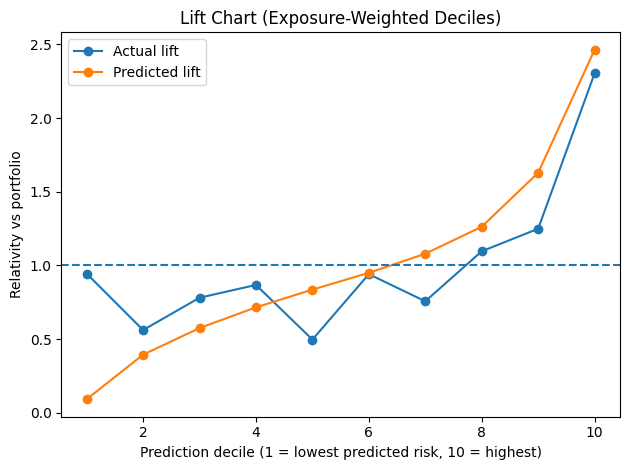

In [10]:
g, port_act, port_pred = lift_table_by_decile(
    df_test, y_pp_col="pure_premium_capped_1MIL", pred_pp=df_test["pred_ols"].to_numpy(), exposure_col="Exposure"
)

print(g[["decile","exposure","actual_pp","pred_pp","actual_lift","pred_lift"]].to_string(index=False))
plot_lift(g)

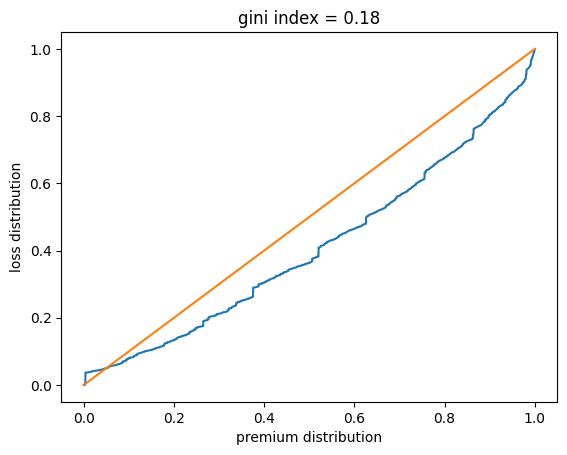

np.float64(0.183555017495183)

In [ ]:
orderedLorenz(df_test['ClaimAmount_capped_1MIL'], df_test['pred_int'], df_test['pred_ols'], plot=True)

## GLM Performance

 decile    exposure  actual_pp    pred_pp  actual_lift  pred_lift
      1 7161.084631 133.111052  31.511967     0.862214   0.388404
      2 7161.247570  82.391243  43.270993     0.533681   0.533341
      3 7161.103967  92.438876  50.706936     0.598764   0.624993
      4 7161.232148 102.413443  57.028106     0.663373   0.702906
      5 7161.171660 155.780952  63.231357     1.009056   0.779364
      6 7160.968689  90.988610  70.036501     0.589370   0.863242
      7 7161.359795 177.855378  78.292598     1.152041   0.965003
      8 7161.413593 158.775430  89.694338     1.028452   1.105536
      9 7160.899122 166.952987 111.946855     1.081421   1.379812
     10 7161.661465 383.103717 215.591120     2.481516   2.657290


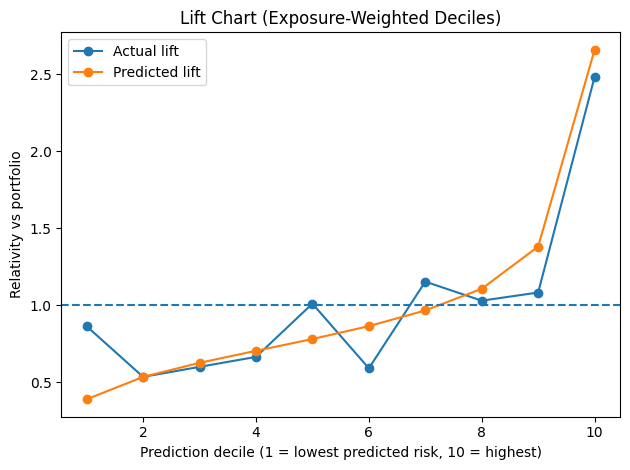

In [12]:
g, port_act, port_pred = lift_table_by_decile(
    df_test, y_pp_col="pure_premium_capped_1MIL", pred_pp=df_test["pred_glm"].to_numpy(), exposure_col="Exposure"
)

print(g[["decile","exposure","actual_pp","pred_pp","actual_lift","pred_lift"]].to_string(index=False))
plot_lift(g)

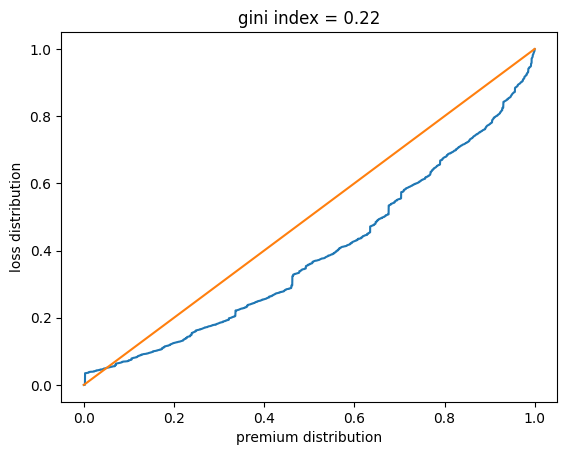

np.float64(0.2172553380203135)

In [42]:
orderedLorenz(df_test['ClaimAmount_capped_1MIL'], df_test['pred_int'], df_test['pred_glm'], plot=True)

## GBM Performance

 decile    exposure  actual_pp    pred_pp  actual_lift  pred_lift
      1 7161.028197 108.136281  13.911748     0.700442   0.231032
      2 7161.301015 160.409392  24.968872     1.039036   0.414657
      3 7160.827232  78.258301  32.191224     0.506910   0.534598
      4 7161.547810 102.075998  38.675575     0.661187   0.642283
      5 7161.125887  73.814245  45.015764     0.478124   0.747574
      6 7161.392017 153.230217  51.732532     0.992534   0.859119
      7 7160.322572 157.298411  59.783276     1.018885   0.992817
      8 7162.127245 109.700055  70.753597     0.710571   1.175001
      9 7160.601267 165.253557  89.562920     1.070414   1.487366
     10 7161.869400 435.629945 175.551639     2.821750   2.915376


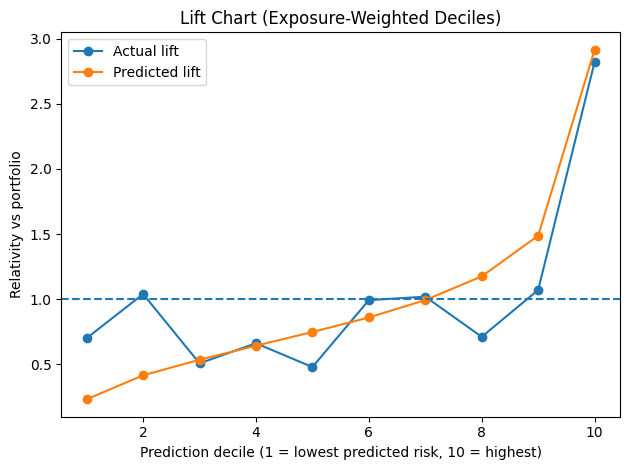

In [33]:
g, port_act, port_pred = lift_table_by_decile(
    df_test, y_pp_col="pure_premium_capped_1MIL", pred_pp=df_test["pred_xgb"].to_numpy(), exposure_col="Exposure"
)

print(g[["decile","exposure","actual_pp","pred_pp","actual_lift","pred_lift"]].to_string(index=False))
plot_lift(g)

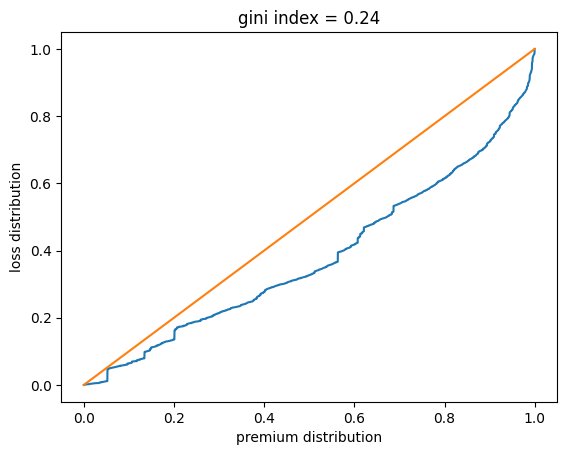

np.float64(0.24287694396718373)

In [43]:
orderedLorenz(df_test['ClaimAmount_capped_1MIL'], df_test['pred_int'], df_test['pred_xgb'], plot=True)

## Compare to Each Other

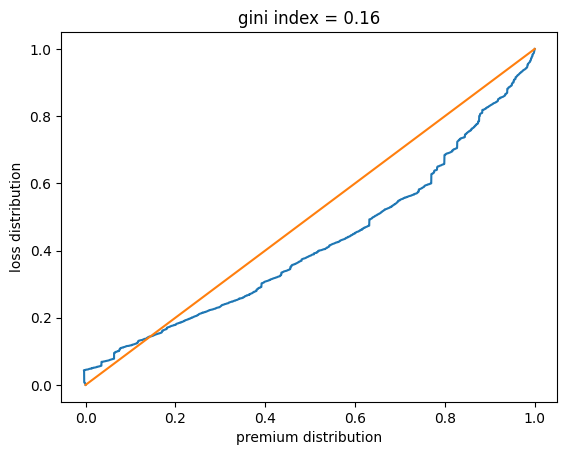

np.float64(0.15798070767129369)

In [44]:
orderedLorenz(df_test['ClaimAmount_capped_1MIL'], df_test['pred_ols'], df_test['pred_glm'], plot=True)

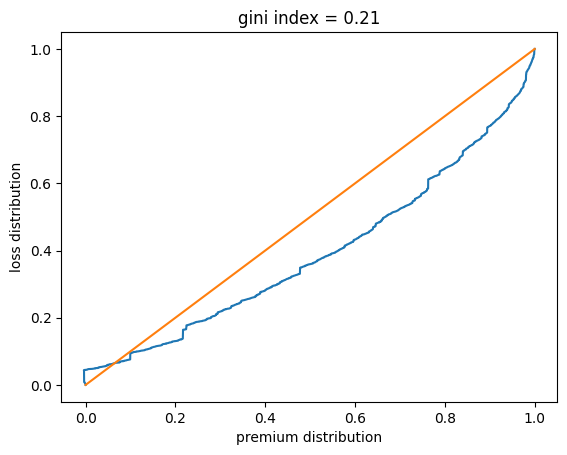

np.float64(0.21461141636733794)

In [45]:
orderedLorenz(df_test['ClaimAmount_capped_1MIL'], df_test['pred_ols'], df_test['pred_xgb'], plot=True)

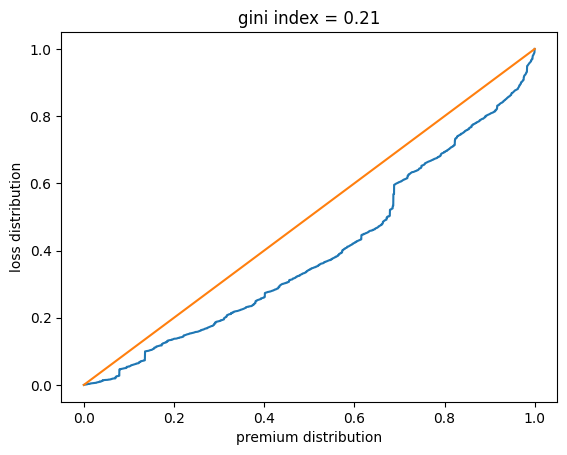

np.float64(0.20898576563634075)

In [47]:
orderedLorenz(df_test['ClaimAmount_capped_1MIL'], df_test['pred_glm'], df_test['pred_xgb'], plot=True)

# Conclusions

Overall, the GBM method seems to outperform the GLM in terms of out-of-sample lift and Gini. This is not surprising, as the GBM is able to recognize non-linear fit and interaction terms. 

However, the GBM provides very little transparency about the internal workings of the model, so spending more time refining the GLM may a good investment.

This is currently a **huge** point of contention between the data science team, actuaries and external regulators at my company right now and these same debates are playing out all over the industry right now.